# IR Conversion Uplift Waterfall Charts

This notebook generates waterfall charts showing the cumulative impact of various initiatives on IR conversion rate improvement.

**Key distinction:**
- **Incremental Uplift** (yellow): Real business impact that drives additional conversions and revenue
- **Baseline Correction** (gray): Measurement adjustment that improves the conversion rate metric but doesn't generate new conversions

**Note:** Incremental initiatives start after the baseline's HIGH estimate to avoid visual overlap with the baseline uncertainty range.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Hertz brand colors
HERTZ_YELLOW = '#F5C400'
HERTZ_CHARCOAL = '#1A1A1A'
HERTZ_DARK_GRAY = '#6E6E6E'
HERTZ_LIGHT_GRAY = '#E6E6E6'

# Set default styling
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = HERTZ_LIGHT_GRAY
plt.rcParams['axes.labelcolor'] = HERTZ_CHARCOAL
plt.rcParams['xtick.color'] = HERTZ_CHARCOAL
plt.rcParams['ytick.color'] = HERTZ_CHARCOAL

In [44]:
# Load the data
xlsx = pd.ExcelFile('../data/raw/260126_IR-upliftsizing.xlsx', engine='openpyxl')
df = pd.read_excel(xlsx, sheet_name='Summary', header=None)

# Extract initiative data (rows 16-28, skipping header row 15)
data = df.iloc[16:29, [0, 1, 6, 7, 10, 11]].copy()
data.columns = ['#', 'Initiative', 'Category', 'Uplift_Lever', 'Uplift_pp_LOW', 'Uplift_pp_HIGH']
data = data.reset_index(drop=True)

# Convert uplift values to percentage points (multiply by 100)
data['Uplift_pp_LOW'] = pd.to_numeric(data['Uplift_pp_LOW'], errors='coerce') * 100
data['Uplift_pp_HIGH'] = pd.to_numeric(data['Uplift_pp_HIGH'], errors='coerce') * 100

# Mark baseline correction initiative
data['is_baseline'] = data['#'].astype(str) == '1'

print(data[['#', 'Uplift_Lever', 'Uplift_pp_LOW', 'Uplift_pp_HIGH', 'is_baseline']].to_string())

        #                        Uplift_Lever  Uplift_pp_LOW  Uplift_pp_HIGH  is_baseline
0       1  Baseline Adjustment (remove noise)       2.191329        3.804335         True
1       2              Higher Counter Contact       0.375747        0.751493        False
2       3               Higher HRD Conversion       1.441758        1.441758        False
3       4               Higher HRD Conversion       1.111431        1.111431        False
4       5               Higher MMR Completion       0.253540        0.507079        False
5       6               Higher MMR Completion       0.380441        0.634069        False
6     5-6               Higher MMR Completion       0.038045        0.126818        False
7       7              Faster Counter Contact       0.674009        0.674009        False
8       8              Faster Counter Contact       0.674009        0.674009        False
9       9         Improved Counter Conversion       0.608643        0.608643        False
10     10 

## Chart 1: Vertical Waterfall by Uplift Lever

In [45]:
# Aggregate data by Uplift Lever
lever_data = data.groupby('Uplift_Lever').agg({
    'Uplift_pp_LOW': 'sum',
    'Uplift_pp_HIGH': 'sum',
    '#': lambda x: ', '.join(x.astype(str)),
    'is_baseline': 'any'
}).reset_index()

# Define the order and display names for levers
lever_order = [
    ('Baseline Adjustment (remove noise)', 'Baseline\nAdjustment', '(1)'),
    ('Higher Counter Contact', 'Higher Counter\nContact', '(2)'),
    ('Higher HRD Conversion', 'Higher HRD\nConversion', '(3, 4)'),
    ('Higher MMR Completion', 'Higher MMR\nCompletion', '(5, 6, 5-6)'),
    ('Faster Counter Contact', 'Faster Counter\nContact', '(7, 8)'),
    ('Improved Counter Conversion', 'Improved Counter\nConversion', '(9, 10, 11)'),
    ('Reduced Competitor Flips', 'Reduced\nCompetitor Flips', '(12-13)')
]

# Build ordered data
ordered_levers = []
for lever_name, display_name, initiatives in lever_order:
    row = lever_data[lever_data['Uplift_Lever'] == lever_name]
    if not row.empty:
        ordered_levers.append({
            'lever': display_name,
            'initiatives': initiatives,
            'low': row['Uplift_pp_LOW'].values[0],
            'high': row['Uplift_pp_HIGH'].values[0],
            'is_baseline': row['is_baseline'].values[0]
        })

lever_df = pd.DataFrame(ordered_levers)
lever_df['delta'] = lever_df['high'] - lever_df['low']
print(lever_df)

                          lever  initiatives       low      high  is_baseline  \
0          Baseline\nAdjustment          (1)  2.191329  3.804335         True   
1       Higher Counter\nContact          (2)  0.375747  0.751493        False   
2        Higher HRD\nConversion       (3, 4)  2.553189  2.553189        False   
3        Higher MMR\nCompletion  (5, 6, 5-6)  0.672026  1.267966        False   
4       Faster Counter\nContact       (7, 8)  1.348017  1.348017        False   
5  Improved Counter\nConversion  (9, 10, 11)  1.825929  1.825929        False   
6     Reduced\nCompetitor Flips      (12-13)  1.237500  1.237500        False   

      delta  
0  1.613006  
1  0.375747  
2  0.000000  
3  0.595939  
4  0.000000  
5  0.000000  
6  0.000000  


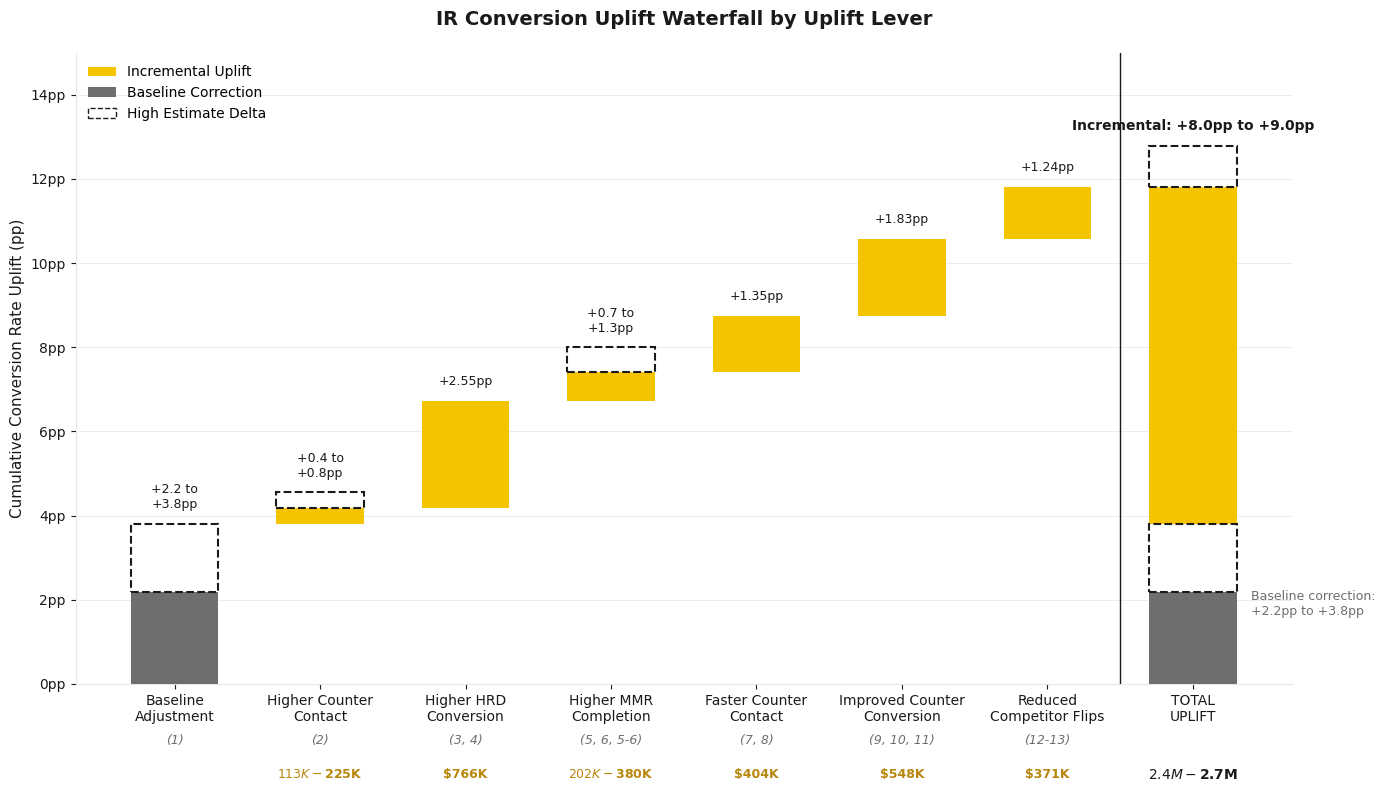


=== VALUE VERIFICATION ===
Value per pp: $300,000

Individual incremental levers:
  Higher Counter Contact: $113K - $225K
  Higher HRD Conversion: $766K - $766K
  Higher MMR Completion: $202K - $380K
  Faster Counter Contact: $404K - $404K
  Improved Counter Conversion: $548K - $548K
  Reduced Competitor Flips: $371K - $371K

Sum of incremental levers: $2.4M - $2.7M
Total shown on chart:      $2.4M - $2.7M
Match: False


In [46]:
fig, ax = plt.subplots(figsize=(14, 8))

n_bars = len(lever_df) + 1  # +1 for total
x = np.arange(n_bars)
bar_width = 0.6

# Value conversion: 0.2pp = $60,000, so 1pp = $300,000
VALUE_PER_PP = 300000

# Calculate totals
baseline_low = lever_df[lever_df['is_baseline']]['low'].sum()
baseline_high = lever_df[lever_df['is_baseline']]['high'].sum()
real_low = lever_df[~lever_df['is_baseline']]['low'].sum()
real_high = lever_df[~lever_df['is_baseline']]['high'].sum()

# Calculate cumulative positions
# KEY: Initiative 2 starts at baseline's HIGH, others stack on LOW
bottoms = []
cumulative = 0
for i, row in lever_df.iterrows():
    if i == 0:  # First bar (baseline) starts at 0
        bottoms.append(0)
        cumulative = row['high']  # Next bar starts at baseline's HIGH
    else:
        bottoms.append(cumulative)
        cumulative += row['low']  # Subsequent bars stack on LOW

bottoms.append(0)  # Total bar starts at 0

# Draw bars for each lever
for i, row in lever_df.iterrows():
    bar_color = HERTZ_DARK_GRAY if row['is_baseline'] else HERTZ_YELLOW
    
    ax.bar(i, row['low'], bar_width, bottom=bottoms[i], 
           color=bar_color, edgecolor='none', zorder=3)
    
    if row['delta'] > 0.01:
        rect = mpatches.FancyBboxPatch(
            (i - bar_width/2, bottoms[i] + row['low']), 
            bar_width, row['delta'],
            boxstyle='square,pad=0',
            facecolor='none', 
            edgecolor=HERTZ_CHARCOAL,
            linestyle='--',
            linewidth=1.5,
            zorder=4
        )
        ax.add_patch(rect)

# Total bar - gray baseline with dashed range, then yellow incremental on top
# Gray solid: 0 to baseline_low
ax.bar(n_bars - 1, baseline_low, bar_width, bottom=0, 
       color=HERTZ_DARK_GRAY, edgecolor='none', zorder=3)

# Gray dashed: baseline_low to baseline_high
baseline_delta = baseline_high - baseline_low
rect = mpatches.FancyBboxPatch(
    (n_bars - 1 - bar_width/2, baseline_low), 
    bar_width, baseline_delta,
    boxstyle='square,pad=0',
    facecolor='none', 
    edgecolor=HERTZ_CHARCOAL,
    linestyle='--',
    linewidth=1.5,
    zorder=4
)
ax.add_patch(rect)

# Yellow solid: starts at baseline_high, height = real_low
ax.bar(n_bars - 1, real_low, bar_width, bottom=baseline_high, 
       color=HERTZ_YELLOW, edgecolor='none', zorder=3)

# Yellow dashed: real uplift delta at top
real_delta = real_high - real_low
rect = mpatches.FancyBboxPatch(
    (n_bars - 1 - bar_width/2, baseline_high + real_low), 
    bar_width, real_delta,
    boxstyle='square,pad=0',
    facecolor='none', 
    edgecolor=HERTZ_CHARCOAL,
    linestyle='--',
    linewidth=1.5,
    zorder=4
)
ax.add_patch(rect)

# Add vertical line before total
ax.axvline(x=n_bars - 1.5, color=HERTZ_CHARCOAL, linewidth=1, zorder=2)

# Add labels above bars
for i, row in lever_df.iterrows():
    if row['delta'] > 0.01:
        label = f"+{row['low']:.1f} to\n+{row['high']:.1f}pp"
        y_pos = bottoms[i] + row['high'] + 0.3
    else:
        label = f"+{row['low']:.2f}pp"
        y_pos = bottoms[i] + row['low'] + 0.3
    ax.text(i, y_pos, label, ha='center', va='bottom', fontsize=9, color=HERTZ_CHARCOAL)

# Total labels
ax.text(n_bars - 1, baseline_high + real_high + 0.3, 
        f"Incremental: +{real_low:.1f}pp to +{real_high:.1f}pp", 
        ha='center', va='bottom', fontsize=10, fontweight='bold', color=HERTZ_CHARCOAL)

ax.text(n_bars - 1 + bar_width/2 + 0.1, baseline_high/2, 
        f"Baseline correction:\n+{baseline_low:.1f}pp to +{baseline_high:.1f}pp", 
        ha='left', va='center', fontsize=9, color=HERTZ_DARK_GRAY)

# X-axis labels
labels = list(lever_df['lever']) + ['TOTAL\nUPLIFT']
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)

# Add initiative numbers below x-axis labels
initiatives = list(lever_df['initiatives']) + ['']
for i, init in enumerate(initiatives):
    if init:
        ax.text(i, -1.2, init, ha='center', va='top', fontsize=9, 
                color=HERTZ_DARK_GRAY, style='italic')

# Helper function to format currency
def format_currency(val):
    if val >= 1_000_000:
        return f"${val/1_000_000:.1f}M"
    elif val >= 1_000:
        return f"${val/1_000:.0f}K"
    else:
        return f"${val:.0f}"

# Add dollar values below initiative numbers (only for incremental, not baseline)
for i, row in lever_df.iterrows():
    if row['is_baseline']:
        # Skip baseline - no dollar value
        continue
    
    low_val = row['low'] * VALUE_PER_PP
    high_val = row['high'] * VALUE_PER_PP
    
    if row['delta'] > 0.01:
        value_label = f"{format_currency(low_val)} - {format_currency(high_val)}"
    else:
        value_label = format_currency(low_val)
    
    ax.text(i, -2.0, value_label, ha='center', va='top', fontsize=9, 
            color='#B8860B', fontweight='bold')

# Add total value below TOTAL UPLIFT (only incremental value, not baseline)
total_low = real_low * VALUE_PER_PP
total_high = real_high * VALUE_PER_PP
total_value_label = f"{format_currency(total_low)} - {format_currency(total_high)}"
ax.text(n_bars - 1, -2.0, total_value_label, ha='center', va='top', fontsize=10, 
        color=HERTZ_CHARCOAL, fontweight='bold')

# Y-axis
ax.set_ylabel('Cumulative Conversion Rate Uplift (pp)', fontsize=11, color=HERTZ_CHARCOAL)
ax.set_ylim(0, 15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}pp'))

# Grid
ax.yaxis.grid(True, color=HERTZ_LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=1)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(HERTZ_LIGHT_GRAY)
ax.spines['bottom'].set_color(HERTZ_LIGHT_GRAY)

# Title
ax.set_title('IR Conversion Uplift Waterfall by Uplift Lever', 
             fontsize=14, fontweight='bold', color=HERTZ_CHARCOAL, pad=20)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=HERTZ_YELLOW, edgecolor='none', label='Incremental Uplift'),
    mpatches.Patch(facecolor=HERTZ_DARK_GRAY, edgecolor='none', label='Baseline Correction'),
    mpatches.Patch(facecolor='none', edgecolor=HERTZ_CHARCOAL, linestyle='--', label='High Estimate Delta')
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('../ir_uplift_waterfall_vertical.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Verification: Print breakdown to confirm totals match
print("\n=== VALUE VERIFICATION ===")
print(f"Value per pp: ${VALUE_PER_PP:,}")
print()
print("Individual incremental levers:")
running_low = 0
running_high = 0
for i, row in lever_df.iterrows():
    if not row['is_baseline']:
        low_val = row['low'] * VALUE_PER_PP
        high_val = row['high'] * VALUE_PER_PP
        running_low += low_val
        running_high += high_val
        print(f"  {row['lever'].replace(chr(10), ' ')}: {format_currency(low_val)} - {format_currency(high_val)}")

print()
print(f"Sum of incremental levers: {format_currency(running_low)} - {format_currency(running_high)}")
print(f"Total shown on chart:      {format_currency(total_low)} - {format_currency(total_high)}")
print(f"Match: {running_low == total_low and running_high == total_high}")

## Chart 2: Horizontal Waterfall by Initiative

In [47]:
# Create display labels
name_mapping = {
    '1': '1. Remove Noise Data',
    '2': '2. Update IVR Call Tree',
    '3': '3. HRD Verbiage Update',
    '4': '4. HRD Warm Transfer SOP',
    '5': '5. MMR Page 1 Reminder',
    '6': '6. MMR Page 2 UX Improvements',
    '5-6': '5-6. MMR Interaction Effect',
    '7': '7. Branch: HLES Queue Check',
    '8': '8. Branch: Phone Discipline',
    '9': '9. Branch: Leadership Cascade',
    '10': '10. Branch: Weekly Lead Reviews',
    '11': '11. Branch: Escalation Path',
    '12-13': '12-13. Bodyshop Outreach'
}

data['Label'] = data['#'].astype(str).map(name_mapping)
data['delta'] = data['Uplift_pp_HIGH'] - data['Uplift_pp_LOW']

print(data[['Label', 'Uplift_pp_LOW', 'Uplift_pp_HIGH', 'delta', 'is_baseline']].to_string())

                              Label  Uplift_pp_LOW  Uplift_pp_HIGH     delta  is_baseline
0              1. Remove Noise Data       2.191329        3.804335  1.613006         True
1           2. Update IVR Call Tree       0.375747        0.751493  0.375747        False
2            3. HRD Verbiage Update       1.441758        1.441758  0.000000        False
3          4. HRD Warm Transfer SOP       1.111431        1.111431  0.000000        False
4            5. MMR Page 1 Reminder       0.253540        0.507079  0.253540        False
5     6. MMR Page 2 UX Improvements       0.380441        0.634069  0.253627        False
6       5-6. MMR Interaction Effect       0.038045        0.126818  0.088772        False
7       7. Branch: HLES Queue Check       0.674009        0.674009  0.000000        False
8       8. Branch: Phone Discipline       0.674009        0.674009  0.000000        False
9     9. Branch: Leadership Cascade       0.608643        0.608643  0.000000        False
10  10. Br

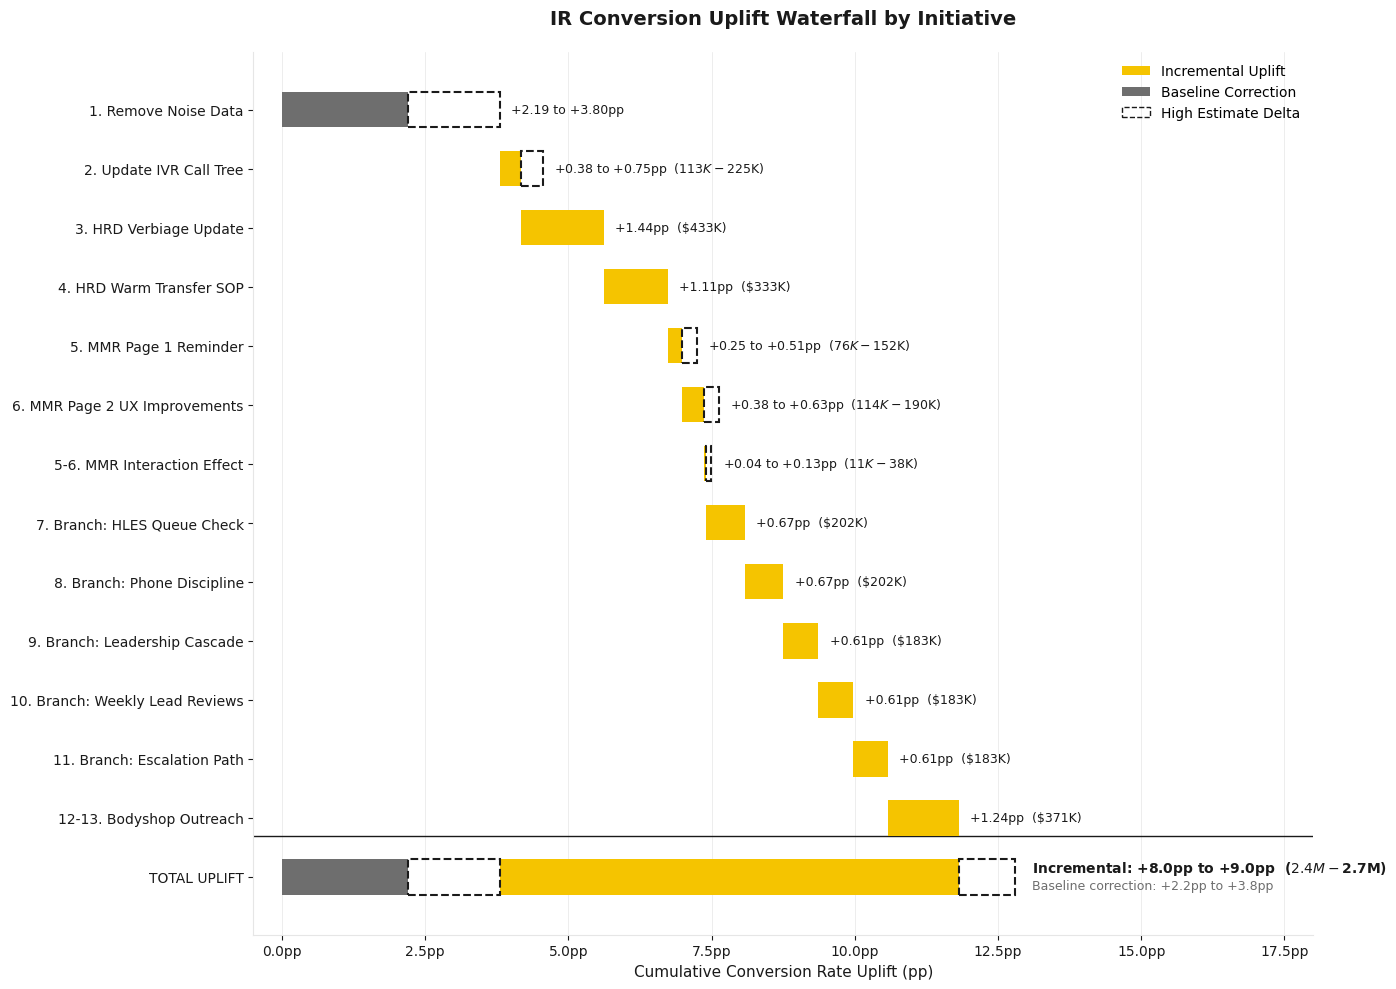


=== VALUE VERIFICATION (Chart 2) ===
Value per pp: $300,000

Individual incremental initiatives:
  2. Update IVR Call Tree: $113K - $225K
  3. HRD Verbiage Update: $433K - $433K
  4. HRD Warm Transfer SOP: $333K - $333K
  5. MMR Page 1 Reminder: $76K - $152K
  6. MMR Page 2 UX Improvements: $114K - $190K
  5-6. MMR Interaction Effect: $11K - $38K
  7. Branch: HLES Queue Check: $202K - $202K
  8. Branch: Phone Discipline: $202K - $202K
  9. Branch: Leadership Cascade: $183K - $183K
  10. Branch: Weekly Lead Reviews: $183K - $183K
  11. Branch: Escalation Path: $183K - $183K
  12-13. Bodyshop Outreach: $371K - $371K

Sum of incremental initiatives: $2.4M - $2.7M
Total shown on chart:           $2.4M - $2.7M
Match: False


In [48]:
fig, ax = plt.subplots(figsize=(14, 10))

n_bars = len(data) + 1  # +1 for total
bar_height = 0.6

# Value conversion: 0.2pp = $60,000, so 1pp = $300,000
VALUE_PER_PP = 300000

# Helper function to format currency
def format_currency(val):
    if val >= 1_000_000:
        return f"${val/1_000_000:.1f}M"
    elif val >= 1_000:
        return f"${val/1_000:.0f}K"
    else:
        return f"${val:.0f}"

# Calculate totals
baseline_low = data[data['is_baseline']]['Uplift_pp_LOW'].sum()
baseline_high = data[data['is_baseline']]['Uplift_pp_HIGH'].sum()
real_low = data[~data['is_baseline']]['Uplift_pp_LOW'].sum()
real_high = data[~data['is_baseline']]['Uplift_pp_HIGH'].sum()

# Calculate cumulative positions
# KEY: Initiative 2 starts at baseline's HIGH, others stack on LOW
lefts = []
cumulative = 0
for i, row in data.iterrows():
    if row['is_baseline']:  # First initiative (baseline) starts at 0
        lefts.append(0)
        cumulative = row['Uplift_pp_HIGH']  # Next starts at baseline's HIGH
    else:
        lefts.append(cumulative)
        cumulative += row['Uplift_pp_LOW']  # Subsequent stack on LOW

lefts.append(0)  # Total bar starts at 0

# Y positions (initiatives from top, total at bottom with gap)
y_positions = list(range(n_bars - 1, 0, -1)) + [0]

# Draw bars for each initiative
for i, (idx, row) in enumerate(data.iterrows()):
    y_pos = y_positions[i]
    bar_color = HERTZ_DARK_GRAY if row['is_baseline'] else HERTZ_YELLOW
    
    ax.barh(y_pos, row['Uplift_pp_LOW'], bar_height, left=lefts[i], 
            color=bar_color, edgecolor='none', zorder=3)
    
    if row['delta'] > 0.01:
        rect = mpatches.FancyBboxPatch(
            (lefts[i] + row['Uplift_pp_LOW'], y_pos - bar_height/2), 
            row['delta'], bar_height,
            boxstyle='square,pad=0',
            facecolor='none', 
            edgecolor=HERTZ_CHARCOAL,
            linestyle='--',
            linewidth=1.5,
            zorder=4
        )
        ax.add_patch(rect)

# Total bar - gray baseline with dashed range, then yellow incremental
# Gray solid: 0 to baseline_low
ax.barh(0, baseline_low, bar_height, left=0, 
        color=HERTZ_DARK_GRAY, edgecolor='none', zorder=3)

# Gray dashed: baseline_low to baseline_high
baseline_delta = baseline_high - baseline_low
rect = mpatches.FancyBboxPatch(
    (baseline_low, 0 - bar_height/2), 
    baseline_delta, bar_height,
    boxstyle='square,pad=0',
    facecolor='none', 
    edgecolor=HERTZ_CHARCOAL,
    linestyle='--',
    linewidth=1.5,
    zorder=4
)
ax.add_patch(rect)

# Yellow solid: starts at baseline_high, width = real_low
ax.barh(0, real_low, bar_height, left=baseline_high, 
        color=HERTZ_YELLOW, edgecolor='none', zorder=3)

# Yellow dashed: real uplift delta at the end
real_delta = real_high - real_low
rect = mpatches.FancyBboxPatch(
    (baseline_high + real_low, 0 - bar_height/2), 
    real_delta, bar_height,
    boxstyle='square,pad=0',
    facecolor='none', 
    edgecolor=HERTZ_CHARCOAL,
    linestyle='--',
    linewidth=1.5,
    zorder=4
)
ax.add_patch(rect)

# Add horizontal line above total
ax.axhline(y=0.7, color=HERTZ_CHARCOAL, linewidth=1, zorder=2)

# Add labels to the right of bars (with dollar values for incremental only)
for i, (idx, row) in enumerate(data.iterrows()):
    y_pos = y_positions[i]
    
    if row['is_baseline']:
        # Baseline: no dollar value
        if row['delta'] > 0.01:
            label = f"+{row['Uplift_pp_LOW']:.2f} to +{row['Uplift_pp_HIGH']:.2f}pp"
            x_pos = lefts[i] + row['Uplift_pp_HIGH'] + 0.2
        else:
            label = f"+{row['Uplift_pp_LOW']:.2f}pp"
            x_pos = lefts[i] + row['Uplift_pp_LOW'] + 0.2
        ax.text(x_pos, y_pos, label, ha='left', va='center', fontsize=9, color=HERTZ_CHARCOAL)
    else:
        # Incremental: include dollar value
        low_val = row['Uplift_pp_LOW'] * VALUE_PER_PP
        high_val = row['Uplift_pp_HIGH'] * VALUE_PER_PP
        
        if row['delta'] > 0.01:
            label = f"+{row['Uplift_pp_LOW']:.2f} to +{row['Uplift_pp_HIGH']:.2f}pp  ({format_currency(low_val)} - {format_currency(high_val)})"
            x_pos = lefts[i] + row['Uplift_pp_HIGH'] + 0.2
        else:
            label = f"+{row['Uplift_pp_LOW']:.2f}pp  ({format_currency(low_val)})"
            x_pos = lefts[i] + row['Uplift_pp_LOW'] + 0.2
        ax.text(x_pos, y_pos, label, ha='left', va='center', fontsize=9, color=HERTZ_CHARCOAL)

# Total labels (only incremental value, not baseline)
total_low_val = real_low * VALUE_PER_PP
total_high_val = real_high * VALUE_PER_PP

ax.text(baseline_high + real_high + 0.3, 0.15, 
        f"Incremental: +{real_low:.1f}pp to +{real_high:.1f}pp  ({format_currency(total_low_val)} - {format_currency(total_high_val)})", 
        ha='left', va='center', fontsize=10, fontweight='bold', color=HERTZ_CHARCOAL)
ax.text(baseline_high + real_high + 0.3, -0.15, 
        f"Baseline correction: +{baseline_low:.1f}pp to +{baseline_high:.1f}pp", 
        ha='left', va='center', fontsize=9, color=HERTZ_DARK_GRAY)

# Y-axis labels
labels = list(data['Label']) + ['TOTAL UPLIFT']
ax.set_yticks(y_positions)
ax.set_yticklabels([labels[i] for i in range(len(data))] + ['TOTAL UPLIFT'], fontsize=10)

# X-axis
ax.set_xlabel('Cumulative Conversion Rate Uplift (pp)', fontsize=11, color=HERTZ_CHARCOAL)
ax.set_xlim(-0.5, 18)  # Increased to fit dollar values
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}pp'))

# Grid
ax.xaxis.grid(True, color=HERTZ_LIGHT_GRAY, linestyle='-', linewidth=0.5, zorder=1)
ax.yaxis.grid(False)
ax.set_axisbelow(True)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(HERTZ_LIGHT_GRAY)
ax.spines['bottom'].set_color(HERTZ_LIGHT_GRAY)

# Title
ax.set_title('IR Conversion Uplift Waterfall by Initiative', 
             fontsize=14, fontweight='bold', color=HERTZ_CHARCOAL, pad=20)

# Legend
legend_elements = [
    mpatches.Patch(facecolor=HERTZ_YELLOW, edgecolor='none', label='Incremental Uplift'),
    mpatches.Patch(facecolor=HERTZ_DARK_GRAY, edgecolor='none', label='Baseline Correction'),
    mpatches.Patch(facecolor='none', edgecolor=HERTZ_CHARCOAL, linestyle='--', label='High Estimate Delta')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig('../ir_uplift_waterfall_horizontal.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Verification: Print breakdown to confirm totals match
print("\n=== VALUE VERIFICATION (Chart 2) ===")
print(f"Value per pp: ${VALUE_PER_PP:,}")
print()
print("Individual incremental initiatives:")
running_low = 0
running_high = 0
for idx, row in data.iterrows():
    if not row['is_baseline']:
        low_val = row['Uplift_pp_LOW'] * VALUE_PER_PP
        high_val = row['Uplift_pp_HIGH'] * VALUE_PER_PP
        running_low += low_val
        running_high += high_val
        print(f"  {row['Label']}: {format_currency(low_val)} - {format_currency(high_val)}")

print()
print(f"Sum of incremental initiatives: {format_currency(running_low)} - {format_currency(running_high)}")
print(f"Total shown on chart:           {format_currency(total_low_val)} - {format_currency(total_high_val)}")
print(f"Match: {running_low == total_low_val and running_high == total_high_val}")

In [49]:
print(f"Summary:")
print(f"  Baseline correction: +{baseline_low:.2f}pp to +{baseline_high:.2f}pp")
print(f"  Incremental uplift:  +{real_low:.2f}pp to +{real_high:.2f}pp")
print(f"\nCharts saved to:")
print("  - ir_uplift_waterfall_vertical.png")
print("  - ir_uplift_waterfall_horizontal.png")

Summary:
  Baseline correction: +2.19pp to +3.80pp
  Incremental uplift:  +8.01pp to +8.98pp

Charts saved to:
  - ir_uplift_waterfall_vertical.png
  - ir_uplift_waterfall_horizontal.png
